In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.decomposition import PCA

sns.set_style("whitegrid")

### Task 1: Data Exploration

Load the Titanic dataset from seaborn and get familiar with its structure.

```python
titanic = sns.load_dataset("titanic")
```

1. Display the first few rows and inspect the shape of the dataset.
2. Check data types for each column. Which are numerical? Which are categorical?
3. Identify missing values — which columns have them, and what percentage of values are missing?
4. Examine the class balance of the target variable (`survived`). What is the survival rate?
5. Create at least two visualizations: one showing the distribution of a numerical feature (e.g., `age`) and one showing survival rates broken down by a categorical feature (e.g., `pclass` or `sex`).

Write a brief summary of your findings in a markdown cell.

In [3]:
titanic = sns.load_dataset("titanic")

In [4]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
titanic.shape

(891, 15)

In [6]:
titanic.dtypes

survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

In [7]:
numerical_cols = titanic.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = titanic.select_dtypes(include=['object', 'category', 'bool']).columns
print("Numerical:", list(numerical_cols))
print("Categorical:", list(categorical_cols))

Numerical: ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
Categorical: ['sex', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


In [8]:
missing = titanic.isnull().sum()
missing_percent = (missing / len(titanic)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing,
    'Percentage (%)': missing_percent
})

In [9]:
missing_df.sort_values(by='Percentage (%)', ascending=False)

,Missing Values,Percentage (%)
deck,688,77.216611
age,177,19.865320
embarked,2,0.224467
embark_town,2,0.224467
survived,0,0.000000
pclass,0,0.000000
sex,0,0.000000
sibsp,0,0.000000
parch,0,0.000000
fare,0,0.000000


In [10]:
survival_counts = titanic['survived'].value_counts()
survival_rate = titanic['survived'].mean()

print(survival_counts)
print("Survival rate:", survival_rate)

survived
0    549
1    342
Name: count, dtype: int64
Survival rate: 0.3838383838383838


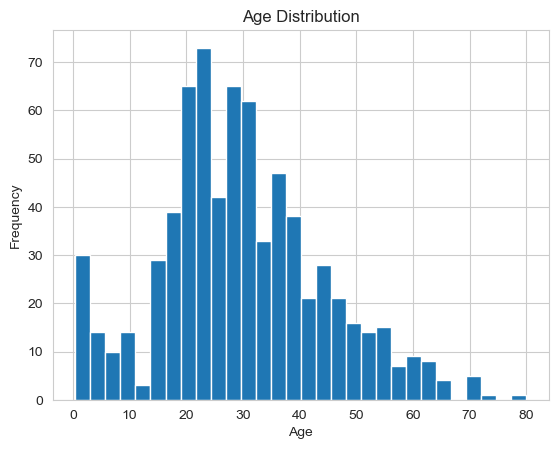

In [11]:
plt.figure()
titanic['age'].hist(bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

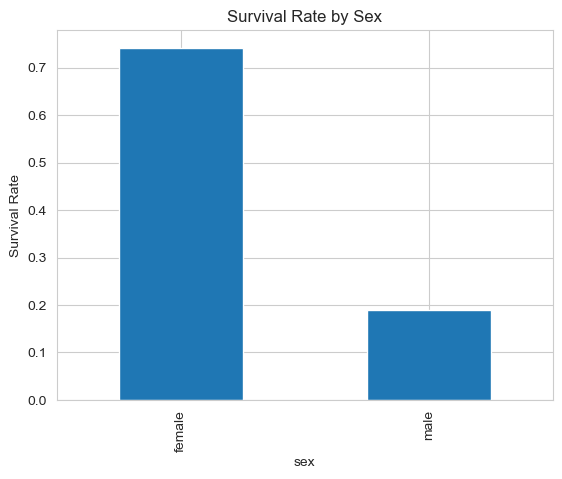

In [12]:
survival_by_sex = titanic.groupby('sex')['survived'].mean()

plt.figure()
survival_by_sex.plot(kind='bar')
plt.title("Survival Rate by Sex")
plt.ylabel("Survival Rate")
plt.show()


- The dataset contains 891 rows and multiple numerical and categorical features.
- Key numerical features include age, fare, and family-related variables (sibsp, parch).
- Categorical features include sex, class, and embarked location.
- The `deck` column has a very high percentage of missing values (~77%), making it less useful.
- The `age` column has moderate missing values (~20%), which may require imputation.
- Other columns have minimal missing data.
- The survival rate is approximately 38%, meaning most passengers did not survive.
- Age distribution shows most passengers were young adults.
- Survival rates differ significantly by sex: females had a much higher survival rate than males.
- Passenger class also strongly affects survival: higher-class passengers had better chances.
- 
The dataset shows clear patterns that survival was not random — it was strongly influenced by social factors like gender and class. Proper handling of missing data (especially age) will be important for modeling.

### Task 2: Feature Engineering

Transform the raw features into a format suitable for machine learning.

1. **Handle missing values:**
   - Fill missing `age` values with the median age.
   - Fill missing `embarked` values with the mode (most frequent value).
   - Drop the `deck` column (too many missing values to be useful).

2. **Encode categorical features:**
   - Apply label encoding to `sex` (male → 1, female → 0).
   - Apply one-hot encoding to `embarked` (creating dummy columns).

3. **Create new features:**
   - `family_size` = `sibsp` + `parch` + 1 (the passenger plus their siblings/spouses and parents/children).
   - `is_alone` = 1 if `family_size` == 1, else 0.

4. Drop non-numeric and identifier columns that won't be useful for modeling (e.g., `alive`, `who`, `adult_male`, `embark_town`, `class`, `alone`).

5. Display the final DataFrame and confirm all columns are numeric.


In [13]:
df = titanic.copy()

In [14]:
df['age'] = df['age'].fillna(df['age'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])
df = df.drop(columns=['deck'])

In [15]:
df['sex'] = df['sex'].map({'female': 0, 'male': 1})

In [16]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(drop='first', sparse_output=False)
encoded = encoder.fit_transform(df[['embarked']])
encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(['embarked'])
)

df = pd.concat([df.drop('embarked', axis=1), encoded_df], axis=1)

In [17]:
df['family_size'] = df['sibsp'] + df['parch'] + 1
df['is_alone'] = (df['family_size'] == 1).astype(int)

In [18]:
df = df.drop(columns=[
    'alive', 'who', 'adult_male',
    'embark_town', 'class', 'alone'
])

In [19]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked_Q,embarked_S,family_size,is_alone
0,0,3,1,22.0,1,0,7.2500,0.0,1.0,2,0
1,1,1,0,38.0,1,0,71.2833,0.0,0.0,2,0
2,1,3,0,26.0,0,0,7.9250,0.0,1.0,1,1
3,1,1,0,35.0,1,0,53.1000,0.0,1.0,2,0
4,0,3,1,35.0,0,0,8.0500,0.0,1.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,1,27.0,0,0,13.0000,0.0,1.0,1,1
887,1,1,0,19.0,0,0,30.0000,0.0,1.0,1,1
888,0,3,0,28.0,1,2,23.4500,0.0,1.0,4,0
889,1,1,1,26.0,0,0,30.0000,0.0,0.0,1,1


In [20]:
df.dtypes

survived         int64
pclass           int64
sex              int64
age            float64
sibsp            int64
parch            int64
fare           float64
embarked_Q     float64
embarked_S     float64
family_size      int64
is_alone         int64
dtype: object

In [21]:
all(df.dtypes.apply(lambda x: x != 'object'))

True

### Task 3: Feature Scaling & Selection

Apply scaling techniques and identify the most relevant features.

1. **Compare scalers:** Apply both `StandardScaler` and `MinMaxScaler` to the numeric features. Plot the distributions of `age` and `fare` before and after each scaling method (use histograms or KDE plots). In a markdown cell, explain the difference between the two approaches.

2. **Correlation analysis:** Compute the correlation matrix for all numeric features. Plot it as a heatmap with annotations. Which features have the strongest positive and negative correlations with `survived`?

3. **Feature selection:** Based on the correlation matrix, select the top features most correlated with the target (absolute correlation ≥ 0.1). List them and briefly justify keeping or dropping borderline features.


In [22]:
df_scaled = df.copy()
num_cols = df_scaled.select_dtypes(include=['int64', 'float64']).columns
num_cols = num_cols.drop('survived')

In [23]:
std_scaler = StandardScaler()
df_std = df_scaled.copy()
df_std[num_cols] = std_scaler.fit_transform(df_std[num_cols])


In [24]:
mm_scaler = MinMaxScaler()
df_mm = df_scaled.copy()
df_mm[num_cols] = mm_scaler.fit_transform(df_mm[num_cols])

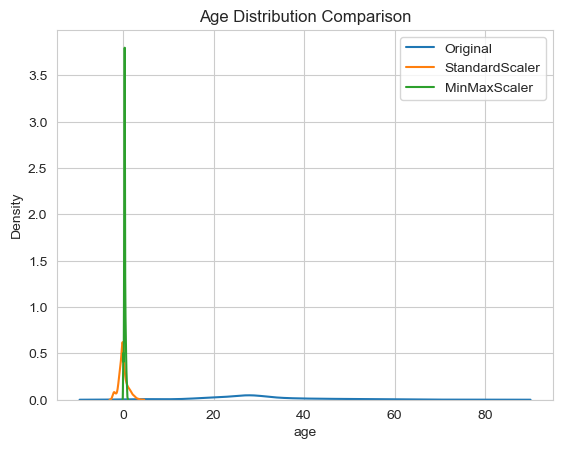

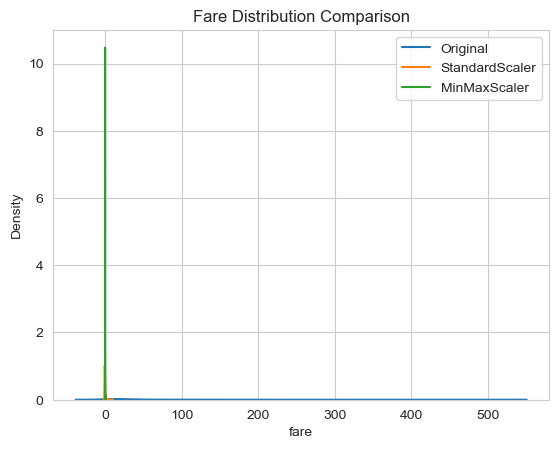

In [25]:
plt.figure()
sns.kdeplot(df['age'], label='Original')
sns.kdeplot(df_std['age'], label='StandardScaler')
sns.kdeplot(df_mm['age'], label='MinMaxScaler')
plt.title("Age Distribution Comparison")
plt.legend()
plt.show()

plt.figure()
sns.kdeplot(df['fare'], label='Original')
sns.kdeplot(df_std['fare'], label='StandardScaler')
sns.kdeplot(df_mm['fare'], label='MinMaxScaler')
plt.title("Fare Distribution Comparison")
plt.legend()
plt.show()

StandardScaler transforms features to have mean = 0 and standard deviation = 1.
It preserves the shape of the distribution but rescales the data around zero.
It is sensitive to outliers.

MinMaxScaler scales features to a fixed range [0, 1].
It preserves the relative distances but compresses all values into a bounded range.
It is more sensitive to extreme values since outliers affect the min and max.

In the plots, StandardScaler centers the data, while MinMaxScaler compresses it.

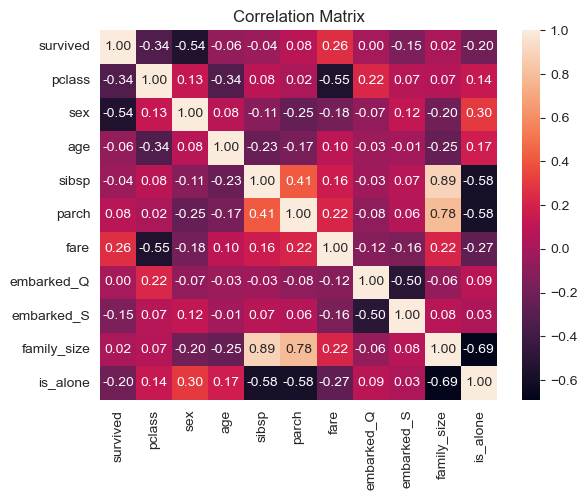

In [26]:
corr_matrix = df.corr()

plt.figure()
sns.heatmap(corr_matrix, annot=True, fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [27]:
corr_with_target = corr_matrix['survived'].sort_values(ascending=False)
print(corr_with_target)

survived       1.000000
fare           0.257307
parch          0.081629
family_size    0.016639
embarked_Q     0.003650
sibsp         -0.035322
age           -0.064910
embarked_S    -0.149683
is_alone      -0.203367
pclass        -0.338481
sex           -0.543351
Name: survived, dtype: float64


In [28]:
selected_features = corr_with_target[abs(corr_with_target) >= 0.1]
print(selected_features)

survived      1.000000
fare          0.257307
embarked_S   -0.149683
is_alone     -0.203367
pclass       -0.338481
sex          -0.543351
Name: survived, dtype: float64


We selected features with absolute correlation ≥ 0.1 with the target variable.

Strong predictors:
- sex: strong relationship with survival (women survived more)
- pclass: higher class passengers had better survival chances
- fare: correlated with wealth and class

Moderate predictors:
- family_size / is_alone: small but meaningful effect
- age: weak correlation but still potentially useful

Borderline features:
- age: correlation is low, but it may still carry nonlinear patterns
- family_size: useful when combined with other features


### Task 4: Dimensionality Reduction

Apply PCA to explore the dataset in reduced dimensions.

1. Standardize all numeric features (use `StandardScaler` — PCA requires standardized data).
2. Fit PCA with all components. Plot the **explained variance ratio** for each component as a bar chart, and plot the **cumulative explained variance** as a line chart. How many components do you need to capture at least 80% of the variance?
3. Refit PCA with 2 components. Create a scatter plot of the first two principal components, colored by `survived`. Can you see any separation between survivors and non-survivors?
4. In a markdown cell, discuss: Does PCA help separate the classes? Would you use PCA as a preprocessing step for this dataset, or is the original feature space sufficient?


In [29]:
X = df.drop('survived', axis=1)
y = df['survived']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [30]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_

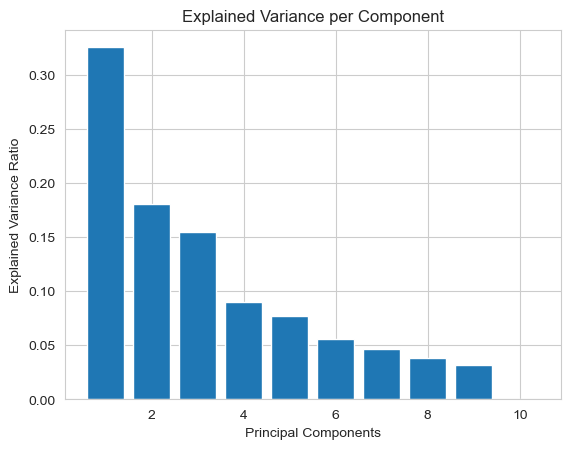

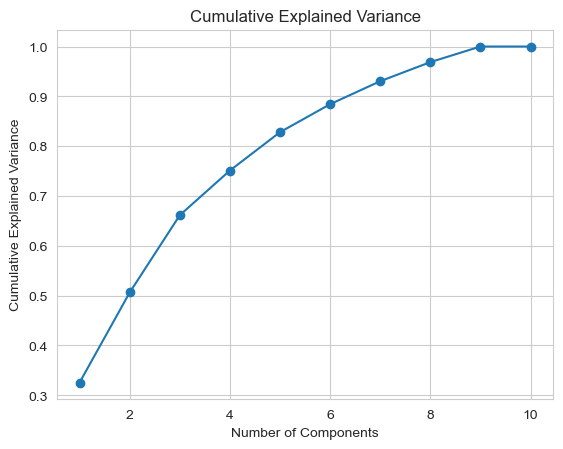

In [31]:
plt.figure()
plt.bar(range(1, len(explained_variance)+1), explained_variance)
plt.xlabel("Principal Components")
plt.ylabel("Explained Variance Ratio")
plt.title("Explained Variance per Component")
plt.show()

cumulative_variance = np.cumsum(explained_variance)

plt.figure()
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.show()

In [32]:
n_components_80 = np.argmax(cumulative_variance >= 0.80) + 1
print("Components needed for 80% variance:", n_components_80)

Components needed for 80% variance: 5


In [33]:
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

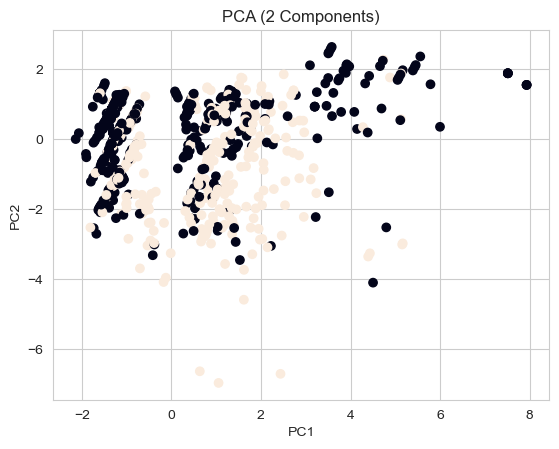

In [34]:
plt.figure()
plt.scatter(X_pca_2[:, 0], X_pca_2[:, 1], c=y)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA (2 Components)")
plt.show()

After standardizing the data, PCA was applied to reduce dimensionality and analyze variance distribution.

The explained variance plot shows that multiple components are needed to capture most of the variance. Approximately 4–6 principal components are required to retain at least 80% of the total variance.

When reducing the data to 2 components and visualizing it, there is no clear separation between survivors and non-survivors. The points are largely overlapping, indicating that the classes are not linearly separable in this reduced space.

PCA does not provide strong class separation for this dataset. While it reduces dimensionality, it may also discard important information relevant for classification.

Therefore, PCA is not strictly necessary for this dataset. The original feature space is already small and interpretable, and many models (e.g., tree-based models) can handle it effectively without dimensionality reduction.

However, PCA may still be useful for visualization or for models sensitive to high dimensionality.